# Extreme precipitation — Kazakhstan: Report visualisations

Loads from cached outputs of the hazard and risk assessment notebooks.
All figures saved to `plots_Kazakhstan/report/`.

In [ ]:
from pathlib import Path

import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import from_levels_and_colors, BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx

AREANAME       = 'Kazakhstan'
RESULTS_HAZARD = Path('.') / f'results_{AREANAME}'
RESULTS_RISK   = Path('.') / f'results_risk_{AREANAME}'
PLOTS_DIR      = Path('.') / f'plots_{AREANAME}' / 'report'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)  

MODELS = [
    'GFDL-ESM4', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'UKESM1-0-LL',
]
RETURN_PERIODS = np.asarray([2, 5, 10, 25, 50, 100, 200, 500])
RP_MAP         = 100    
INTENSITY_TH   = 50     
FREQUENCY_TH   = 10    
POINT_LAT      = 43.25
POINT_LON      = 76.92
POINT_LABEL    = 'Almaty'

TIME_FRAMES = {
    'historical': ('1976', '2005'),
    'ssp126':     ('2041', '2070'),
    'ssp370':     ('2041', '2070'),
}
SCEN_LABELS = {
    'historical': 'Historical 1976-2005',
    'ssp126':     'SSP1-2.6 2041-2070',
    'ssp370':     'SSP3-7.0 2041-2070',
}
SCEN_COLORS = {'historical': 'black', 'ssp126': 'steelblue', 'ssp370': 'tomato'}

_z   = [0., 10., 20, 25, 30, 35, 40, 45, 50, 60., 70., 80, 90., 100., 110, 120., 130, 140]
_rgb = [
    '#ffffff00', '#d6e2ffff', '#8db2ffff', '#626ff7ff', '#0062ffff',
    '#019696ff', '#01c634ff', '#63ff01ff', '#c6ff34ff', '#ffff02ff',
    '#ffc601ff', '#ffa001ff', '#ff7c00ff', '#ff1901ff', '#a20a28ff',
    '#9b159dff', '#d294d3ff', '#f6e9f6ff',
]
CMAP_PREC, NORM_PREC = from_levels_and_colors(_z, _rgb, extend='max')

CMAP_RP   = plt.get_cmap('RdYlGn')
BOUNDS_RP = [0, 2, 5, 10, 20, 50, 100, 200, 500]
NORM_RP   = BoundaryNorm(BOUNDS_RP, CMAP_RP.N)

kaz_gdf      = gpd.read_file(SHAPEFILE_PATH)
kaz_boundary = kaz_gdf.dissolve()


def map_overlay(ax):
    kaz_boundary.boundary.plot(
        ax=ax, color='black', linewidth=0.6, transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
    ctx.add_basemap(
        ax=ax, crs='EPSG:4326',
        source=ctx.providers.CartoDB.Positron,
        attribution_size=6,
    )


def load_idf(scenario):
    y0, y1 = TIME_FRAMES[scenario]
    return xr.open_dataset(
        RESULTS_HAZARD / f'idf_24h_multimodel_{scenario}_{y0}-{y1}.nc'
    )


def load_change(scenario):
    y0, y1 = TIME_FRAMES[scenario]
    return xr.open_dataset(
        RESULTS_HAZARD / f'idf_24h_multimodel_{scenario}_{y0}-{y1}_change.nc'
    )


def load_risk(scenario, varname):
    y0, y1 = TIME_FRAMES[scenario]
    paths = {
        'RP_current':  RESULTS_RISK / f'RP_current_{INTENSITY_TH}mm_{scenario}.nc',
        'RP_shift':    RESULTS_RISK / f'RP_shift_{INTENSITY_TH}mm_{scenario}_{y0}-{y1}.nc',
        'PREC_factor': RESULTS_RISK / f'PREC_factor_{INTENSITY_TH}mm_{scenario}_{y0}-{y1}.nc',
    }
    return xr.open_dataarray(paths[varname])


def load_model_site(model, scenario):
    y0, y1 = TIME_FRAMES[scenario]
    ds = xr.open_dataset(
        RESULTS_HAZARD / f'idf_24h_{model}_{scenario}_{y0}-{y1}.nc'
    )
    da = ds['idf'].sel(lat=POINT_LAT, lon=POINT_LON, method='nearest').values.copy()
    ds.close()
    return da


print('Configuration ready.')

Configuration ready.


## Hazard intensity — historical baseline at multiple return periods

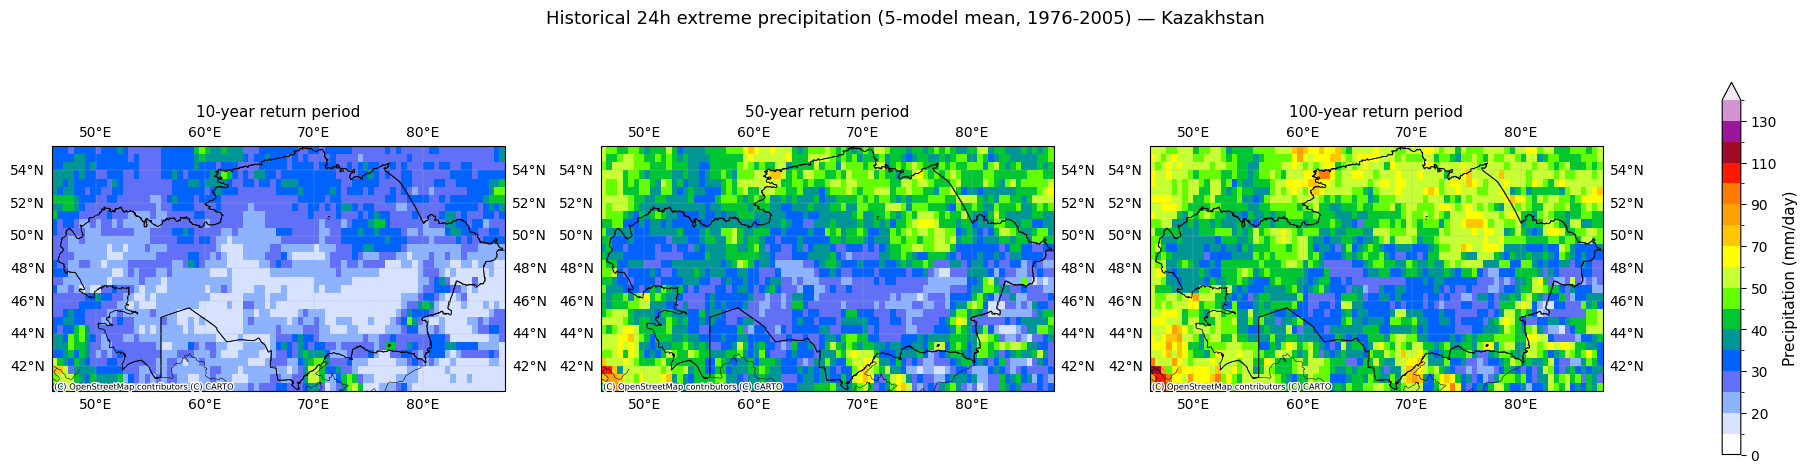

Figure 1 saved.


In [2]:
RPS_PLOT = [10, 50, 100]
ds_h = load_idf('historical')

fig1, axs1 = plt.subplots(
    1, 3, figsize=(18, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)
fig1.suptitle(
    f'Historical 24h extreme precipitation (5-model mean, 1976-2005) — {AREANAME}',
    fontsize=13,
)
for ax, rp in zip(axs1, RPS_PLOT):
    im1 = ds_h['idf'].sel(return_period=rp).plot(
        ax=ax, norm=NORM_PREC, cmap=CMAP_PREC,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    map_overlay(ax)
    ax.set_title(f'{rp}-year return period', fontsize=11)

cbar1 = fig1.colorbar(im1, ax=axs1[:], orientation='vertical', shrink=0.8)
cbar1.set_label('Precipitation (mm/day)', fontsize=11)
fig1.savefig(PLOTS_DIR / 'fig01_historical_idf_maps.png', dpi=150, bbox_inches='tight')
plt.show()
ds_h.close()
print('Figure 1 saved.')

## Projected change — SSP1-2.6 and SSP3-7.0

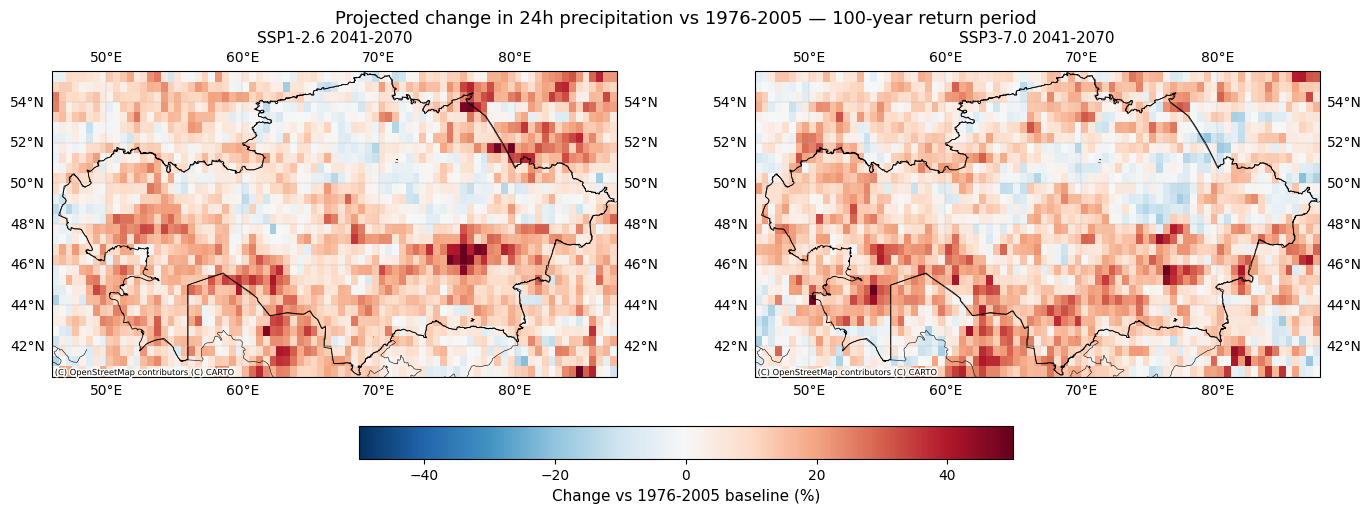

Figure 2 saved.


In [3]:
fig2, axs2 = plt.subplots(
    1, 2, figsize=(14, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)
fig2.suptitle(
    f'Projected change in 24h precipitation vs 1976-2005 — {RP_MAP}-year return period',
    fontsize=13,
)
for ax, scenario in zip(axs2, ['ssp126', 'ssp370']):
    ds_c = load_change(scenario)
    im2 = ds_c['idf_change'].sel(return_period=RP_MAP).plot(
        ax=ax, cmap='RdBu_r', vmin=-50, vmax=50,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    map_overlay(ax)
    ax.set_title(SCEN_LABELS[scenario], fontsize=11)
    ds_c.close()

cbar2 = fig2.colorbar(im2, ax=axs2[:], orientation='horizontal', shrink=0.5, pad=0.08)
cbar2.set_label('Change vs 1976-2005 baseline (%)', fontsize=11)
fig2.savefig(PLOTS_DIR / 'fig02_projected_change_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

## Scenario contrast — SSP3-7.0 minus SSP1-2.6

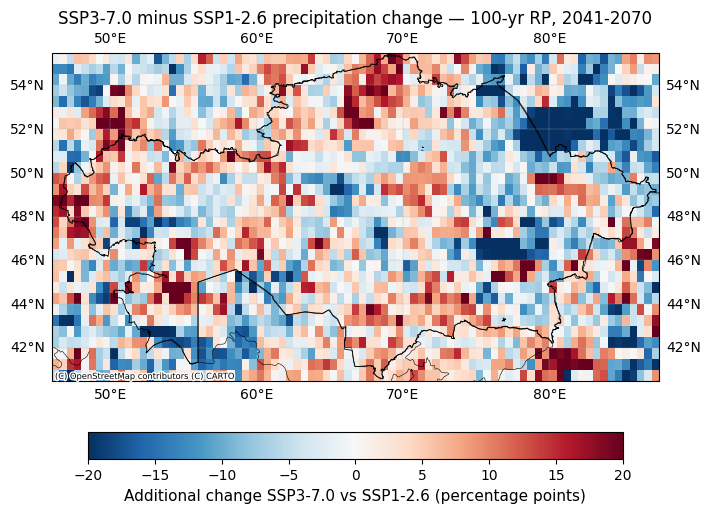

Figure 3 saved.


In [4]:
ds_c126 = load_change('ssp126')
ds_c370 = load_change('ssp370')
da_contrast = (
    ds_c370['idf_change'].sel(return_period=RP_MAP)
    - ds_c126['idf_change'].sel(return_period=RP_MAP)
)

fig3, ax3 = plt.subplots(
    figsize=(9, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)
im3 = da_contrast.plot(
    ax=ax3, cmap='RdBu_r', vmin=-20, vmax=20,
    add_colorbar=False, transform=ccrs.PlateCarree(),
)
map_overlay(ax3)
cbar3 = fig3.colorbar(im3, ax=ax3, orientation='horizontal', shrink=0.6, pad=0.08)
cbar3.set_label('Additional change SSP3-7.0 vs SSP1-2.6 (percentage points)', fontsize=11)
ax3.set_title(
    f'SSP3-7.0 minus SSP1-2.6 precipitation change — {RP_MAP}-yr RP, 2041-2070',
    fontsize=12,
)
fig3.savefig(PLOTS_DIR / 'fig03_scenario_contrast.png', dpi=150, bbox_inches='tight')
plt.show()
ds_c126.close()
ds_c370.close()
print('Figure 3 saved.')

## Frequency curves — spatially averaged IDF over Kazakhstan

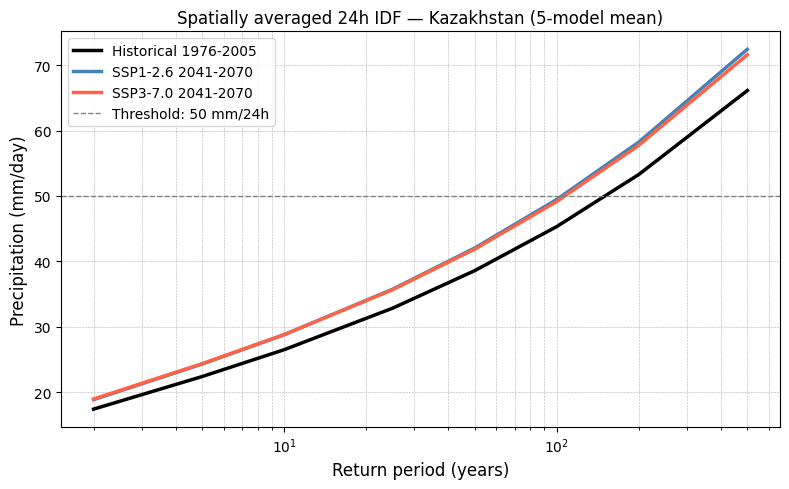

Figure 4 saved.


In [5]:
fig4, ax4 = plt.subplots(figsize=(8, 5))

for scenario in ['historical', 'ssp126', 'ssp370']:
    ds_s   = load_idf(scenario)
    mean_s = ds_s['idf'].mean(dim=['lat', 'lon'], skipna=True).values
    ax4.plot(
        RETURN_PERIODS, mean_s,
        color=SCEN_COLORS[scenario], linewidth=2.5,
        label=SCEN_LABELS[scenario],
    )
    ds_s.close()

ax4.axhline(
    INTENSITY_TH, color='gray', linestyle='--', linewidth=1,
    label=f'Threshold: {INTENSITY_TH} mm/24h',
)
ax4.set_xscale('log')
ax4.set_xlabel('Return period (years)', fontsize=12)
ax4.set_ylabel('Precipitation (mm/day)', fontsize=12)
ax4.set_title(
    f'Spatially averaged 24h IDF — {AREANAME} (5-model mean)', fontsize=12
)
ax4.legend(fontsize=10)
ax4.grid(True, which='both', linestyle='--', linewidth=0.4)
plt.tight_layout()
fig4.savefig(PLOTS_DIR / 'fig04_frequency_curves_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Model spread at example site — Historical and SSP3-7.0

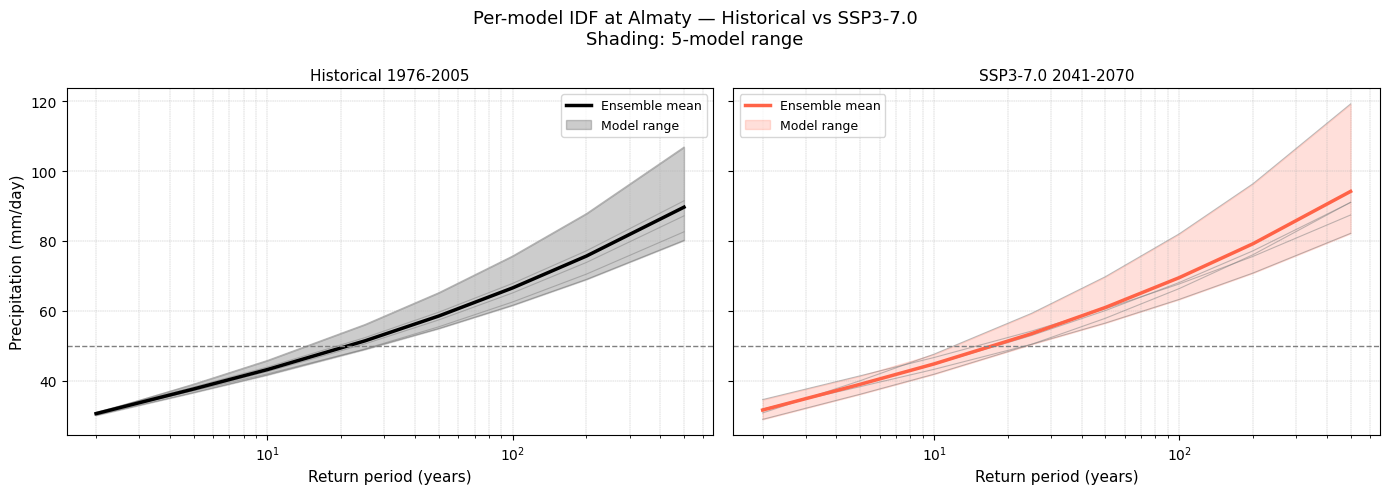

Figure 5 saved.


In [6]:
fig5, axs5 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig5.suptitle(
    f'Per-model IDF at {POINT_LABEL} — Historical vs SSP3-7.0\n'
    f'Shading: 5-model range',
    fontsize=13,
)

for ax, scenario in zip(axs5, ['historical', 'ssp370']):
    curves = np.array([load_model_site(m, scenario) for m in MODELS])
    for row in curves:
        ax.plot(RETURN_PERIODS, row, linewidth=0.8, color='gray', alpha=0.5)
    ax.plot(RETURN_PERIODS, curves.mean(axis=0),
            color=SCEN_COLORS[scenario], linewidth=2.5, label='Ensemble mean')
    ax.fill_between(
        RETURN_PERIODS, curves.min(axis=0), curves.max(axis=0),
        alpha=0.2, color=SCEN_COLORS[scenario], label='Model range',
    )
    ax.axhline(INTENSITY_TH, color='gray', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_xlabel('Return period (years)', fontsize=11)
    ax.set_title(SCEN_LABELS[scenario], fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', linestyle='--', linewidth=0.3)

axs5[0].set_ylabel('Precipitation (mm/day)', fontsize=11)
plt.tight_layout()
fig5.savefig(PLOTS_DIR / 'fig05_model_spread_site.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

## Cross-model uncertainty — coefficient of variation across 5 models

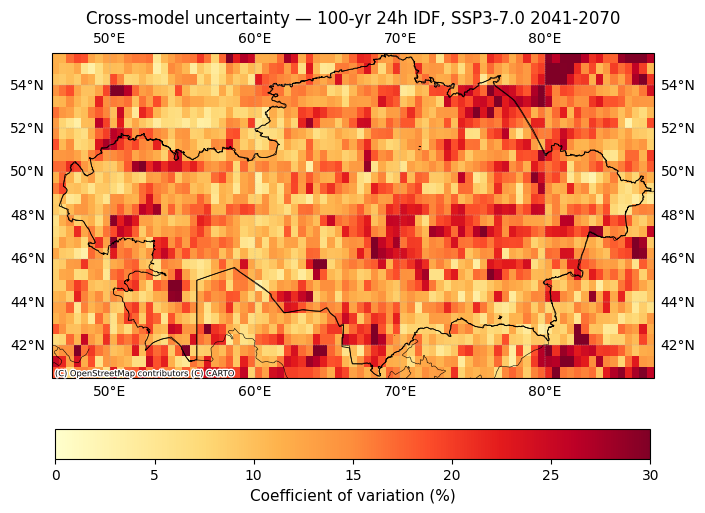

Figure 6 saved.


In [7]:
scenario_unc = 'ssp370'
y0_u, y1_u   = TIME_FRAMES[scenario_unc]

idf_stack = []
for model in MODELS:
    ds_m = xr.open_dataset(
        RESULTS_HAZARD / f'idf_24h_{model}_{scenario_unc}_{y0_u}-{y1_u}.nc'
    )
    idf_stack.append(ds_m['idf'].sel(return_period=RP_MAP))
    ds_m.close()

da_stack = xr.concat(idf_stack, dim='model').assign_coords(model=MODELS)
da_mean  = da_stack.mean(dim='model')
da_std   = da_stack.std(dim='model')
da_cv    = (da_std / da_mean * 100).where(da_mean > 0)

fig6, ax6 = plt.subplots(
    figsize=(10, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)
im6 = da_cv.plot(
    ax=ax6, cmap='YlOrRd', vmin=0, vmax=30,
    add_colorbar=False, transform=ccrs.PlateCarree(),
)
map_overlay(ax6)
cbar6 = fig6.colorbar(im6, ax=ax6, orientation='horizontal', shrink=0.6, pad=0.08)
cbar6.set_label('Coefficient of variation (%)', fontsize=11)
ax6.set_title(
    f'Cross-model uncertainty — {RP_MAP}-yr 24h IDF, {SCEN_LABELS[scenario_unc]}',
    fontsize=12,
)
fig6.savefig(PLOTS_DIR / 'fig06_model_uncertainty_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

## Threshold return period shift — current and future

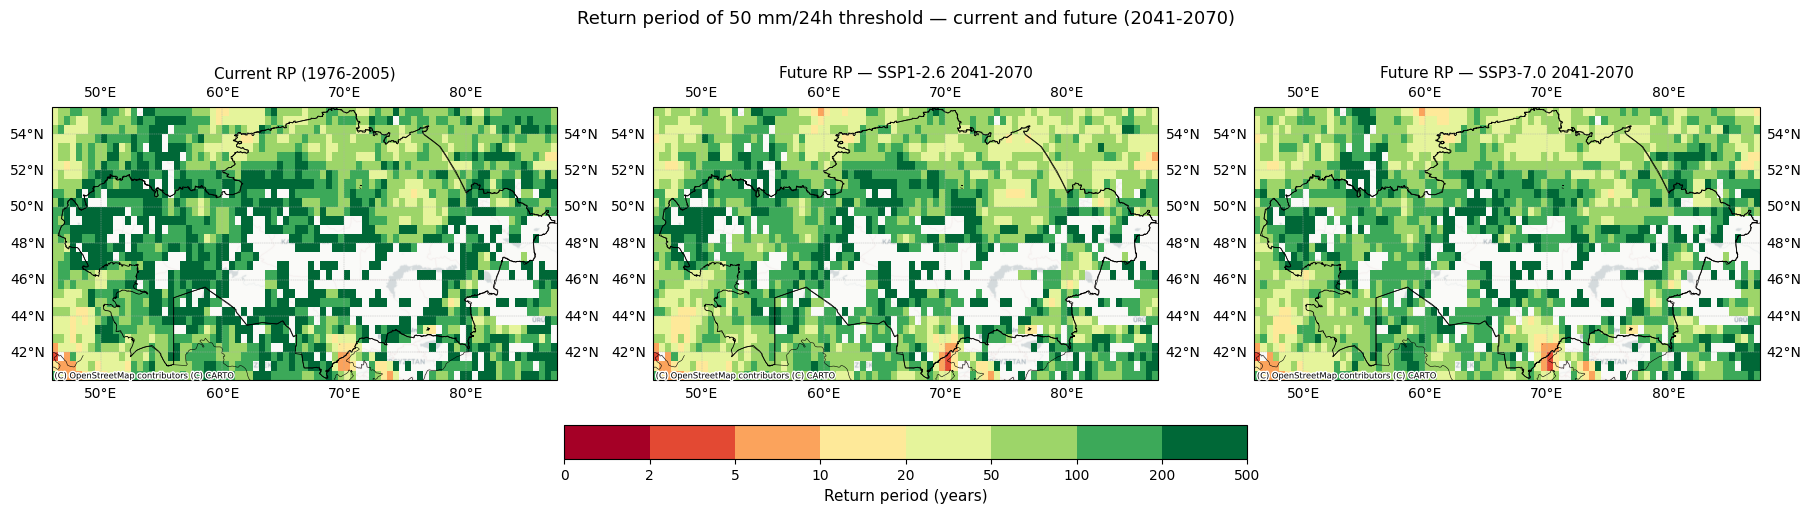

Figure 7 saved.


In [ ]:
da_rp_curr = load_risk('ssp126', 'RP_current')

fig7, axs7 = plt.subplots(
    1, 3, figsize=(18, 5),
    subplot_kw={'projection': ccrs.PlateCarree()},
    constrained_layout=True,
)
fig7.suptitle(
    f'Return period of {INTENSITY_TH} mm/24h threshold — current and future (2041-2070)',
    fontsize=13,
)

im7 = da_rp_curr.plot(
    ax=axs7[0], norm=NORM_RP, cmap=CMAP_RP,
    add_colorbar=False, transform=ccrs.PlateCarree(),
)
map_overlay(axs7[0])
axs7[0].set_title('Current RP (1976-2005)', fontsize=11)

for ax, scenario in zip(axs7[1:], ['ssp126', 'ssp370']):
    da_shift = load_risk(scenario, 'RP_shift')
    im7 = da_shift.plot(
        ax=ax, norm=NORM_RP, cmap=CMAP_RP,
        add_colorbar=False, transform=ccrs.PlateCarree(),
    )
    map_overlay(ax)
    ax.set_title(f'Future RP — {SCEN_LABELS[scenario]}', fontsize=11)
    da_shift.close()

cbar7 = fig7.colorbar(
    im7, ax=axs7[:], ticks=BOUNDS_RP,
    orientation='horizontal', shrink=0.4, pad=0.06,
)
cbar7.set_label('Return period (years)', fontsize=11)
da_rp_curr.close()
fig7.savefig(PLOTS_DIR / 'fig07_rp_shift_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

## Magnitude change distribution — pixel-wise histogram across Kazakhstan

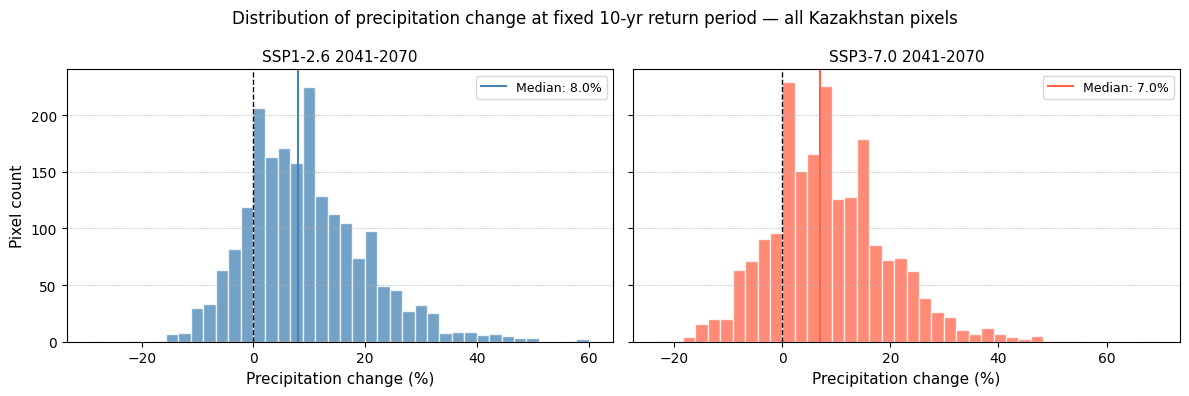

Figure 8 saved.


In [9]:
fig8, axs8 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig8.suptitle(
    f'Distribution of precipitation change at fixed {FREQUENCY_TH}-yr return period'
    f' — all Kazakhstan pixels',
    fontsize=12,
)

for ax, scenario in zip(axs8, ['ssp126', 'ssp370']):
    da_fac = load_risk(scenario, 'PREC_factor')
    pct    = ((da_fac - 1) * 100).values.ravel()
    pct    = pct[~np.isnan(pct)]
    med    = float(np.median(pct))
    ax.hist(pct, bins=40, color=SCEN_COLORS[scenario], alpha=0.75, edgecolor='white')
    ax.axvline(0,   color='black',               linewidth=1.0, linestyle='--')
    ax.axvline(med, color=SCEN_COLORS[scenario], linewidth=1.5,
               label=f'Median: {med:.1f}%')
    ax.set_xlabel('Precipitation change (%)', fontsize=11)
    ax.set_title(SCEN_LABELS[scenario], fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', linewidth=0.4)
    da_fac.close()

axs8[0].set_ylabel('Pixel count', fontsize=11)
plt.tight_layout()
fig8.savefig(PLOTS_DIR / 'fig08_magnitude_change_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

## Exceedance curve at example site with 5-model range

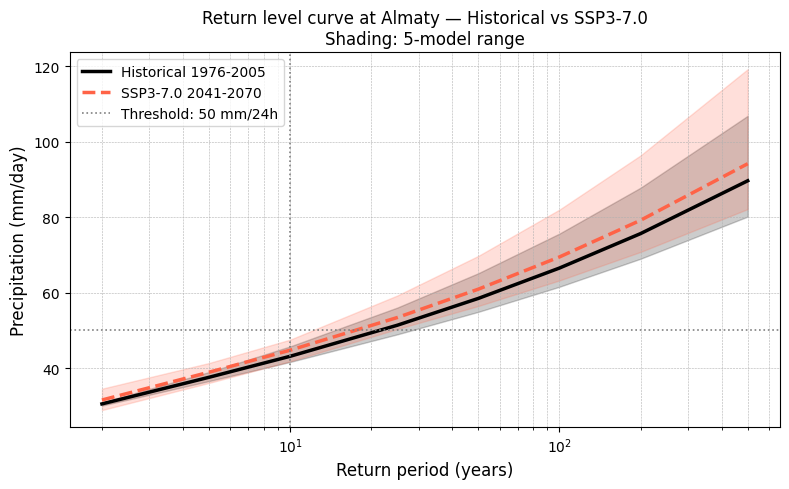

Figure 9 saved.


In [10]:
fig9, ax9 = plt.subplots(figsize=(8, 5))

for scenario in ['historical', 'ssp370']:
    curves = np.array([load_model_site(m, scenario) for m in MODELS])
    mean_v = curves.mean(axis=0)
    color  = SCEN_COLORS[scenario]
    ls     = '-' if scenario == 'historical' else '--'
    ax9.plot(RETURN_PERIODS, mean_v, color=color, linewidth=2.5,
             linestyle=ls, label=SCEN_LABELS[scenario])
    ax9.fill_between(
        RETURN_PERIODS, curves.min(axis=0), curves.max(axis=0),
        alpha=0.2, color=color,
    )

ax9.axhline(
    INTENSITY_TH, color='gray', linestyle=':', linewidth=1.2,
    label=f'Threshold: {INTENSITY_TH} mm/24h',
)
ax9.axvline(
    FREQUENCY_TH, color='gray', linestyle=':', linewidth=1.2,
)
ax9.set_xscale('log')
ax9.set_xlabel('Return period (years)', fontsize=12)
ax9.set_ylabel('Precipitation (mm/day)', fontsize=12)
ax9.set_title(
    f'Return level curve at {POINT_LABEL} — Historical vs SSP3-7.0\n'
    f'Shading: 5-model range',
    fontsize=12,
)
ax9.legend(fontsize=10)
ax9.grid(True, which='both', linestyle='--', linewidth=0.4)
plt.tight_layout()
fig9.savefig(PLOTS_DIR / 'fig09_exceedance_site.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')